<a href="https://colab.research.google.com/github/Killeryoung/ML/blob/main/%D0%9B%D0%A04_%D0%93%D1%83%D1%80%D0%BA%D0%BE_%D0%A4%D0%86%D0%A2_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


In [5]:
import numpy as np
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [7]:
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df = pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))

display(df.head())

Using Colab cache for faster access to the 'car-price-prediction' dataset.


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [22]:
print('Пропущені значення:')
display(df.isna().sum().to_frame('Кількість пропусків'))

print('Повні дублікати (разом із car_ID):', df.duplicated().sum())
content_cols = [c for c in df.columns if c != 'car_ID']
print('Дублікати за змістовими характеристиками (без car_ID):',
      df.duplicated(subset=content_cols).sum())

unique_counts = df.nunique().sort_values()
print('\nКількість унікальних значень:')
display(unique_counts.to_frame('Кількість унікальних'))


Пропущені значення:


,Кількість пропусків
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


Повні дублікати (разом із car_ID): 0
Дублікати за змістовими характеристиками (без car_ID): 0

Кількість унікальних значень:


,Кількість унікальних
fueltype,2
aspiration,2
doornumber,2
enginelocation,2
drivewheel,3
carbody,5
symboling,6
cylindernumber,7
enginetype,7
fuelsystem,8


## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [23]:
car_ids = df['car_ID'].copy()
data = df.drop(columns=['car_ID']).copy()

print('car_ID збережено окремо.')
print('Розмір таблиці без car_ID:', data.shape)
display(car_ids.head().to_frame())


car_ID збережено окремо.
Розмір таблиці без car_ID: (205, 25)


,car_ID
0,1
1,2
2,3
3,4
4,5


## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


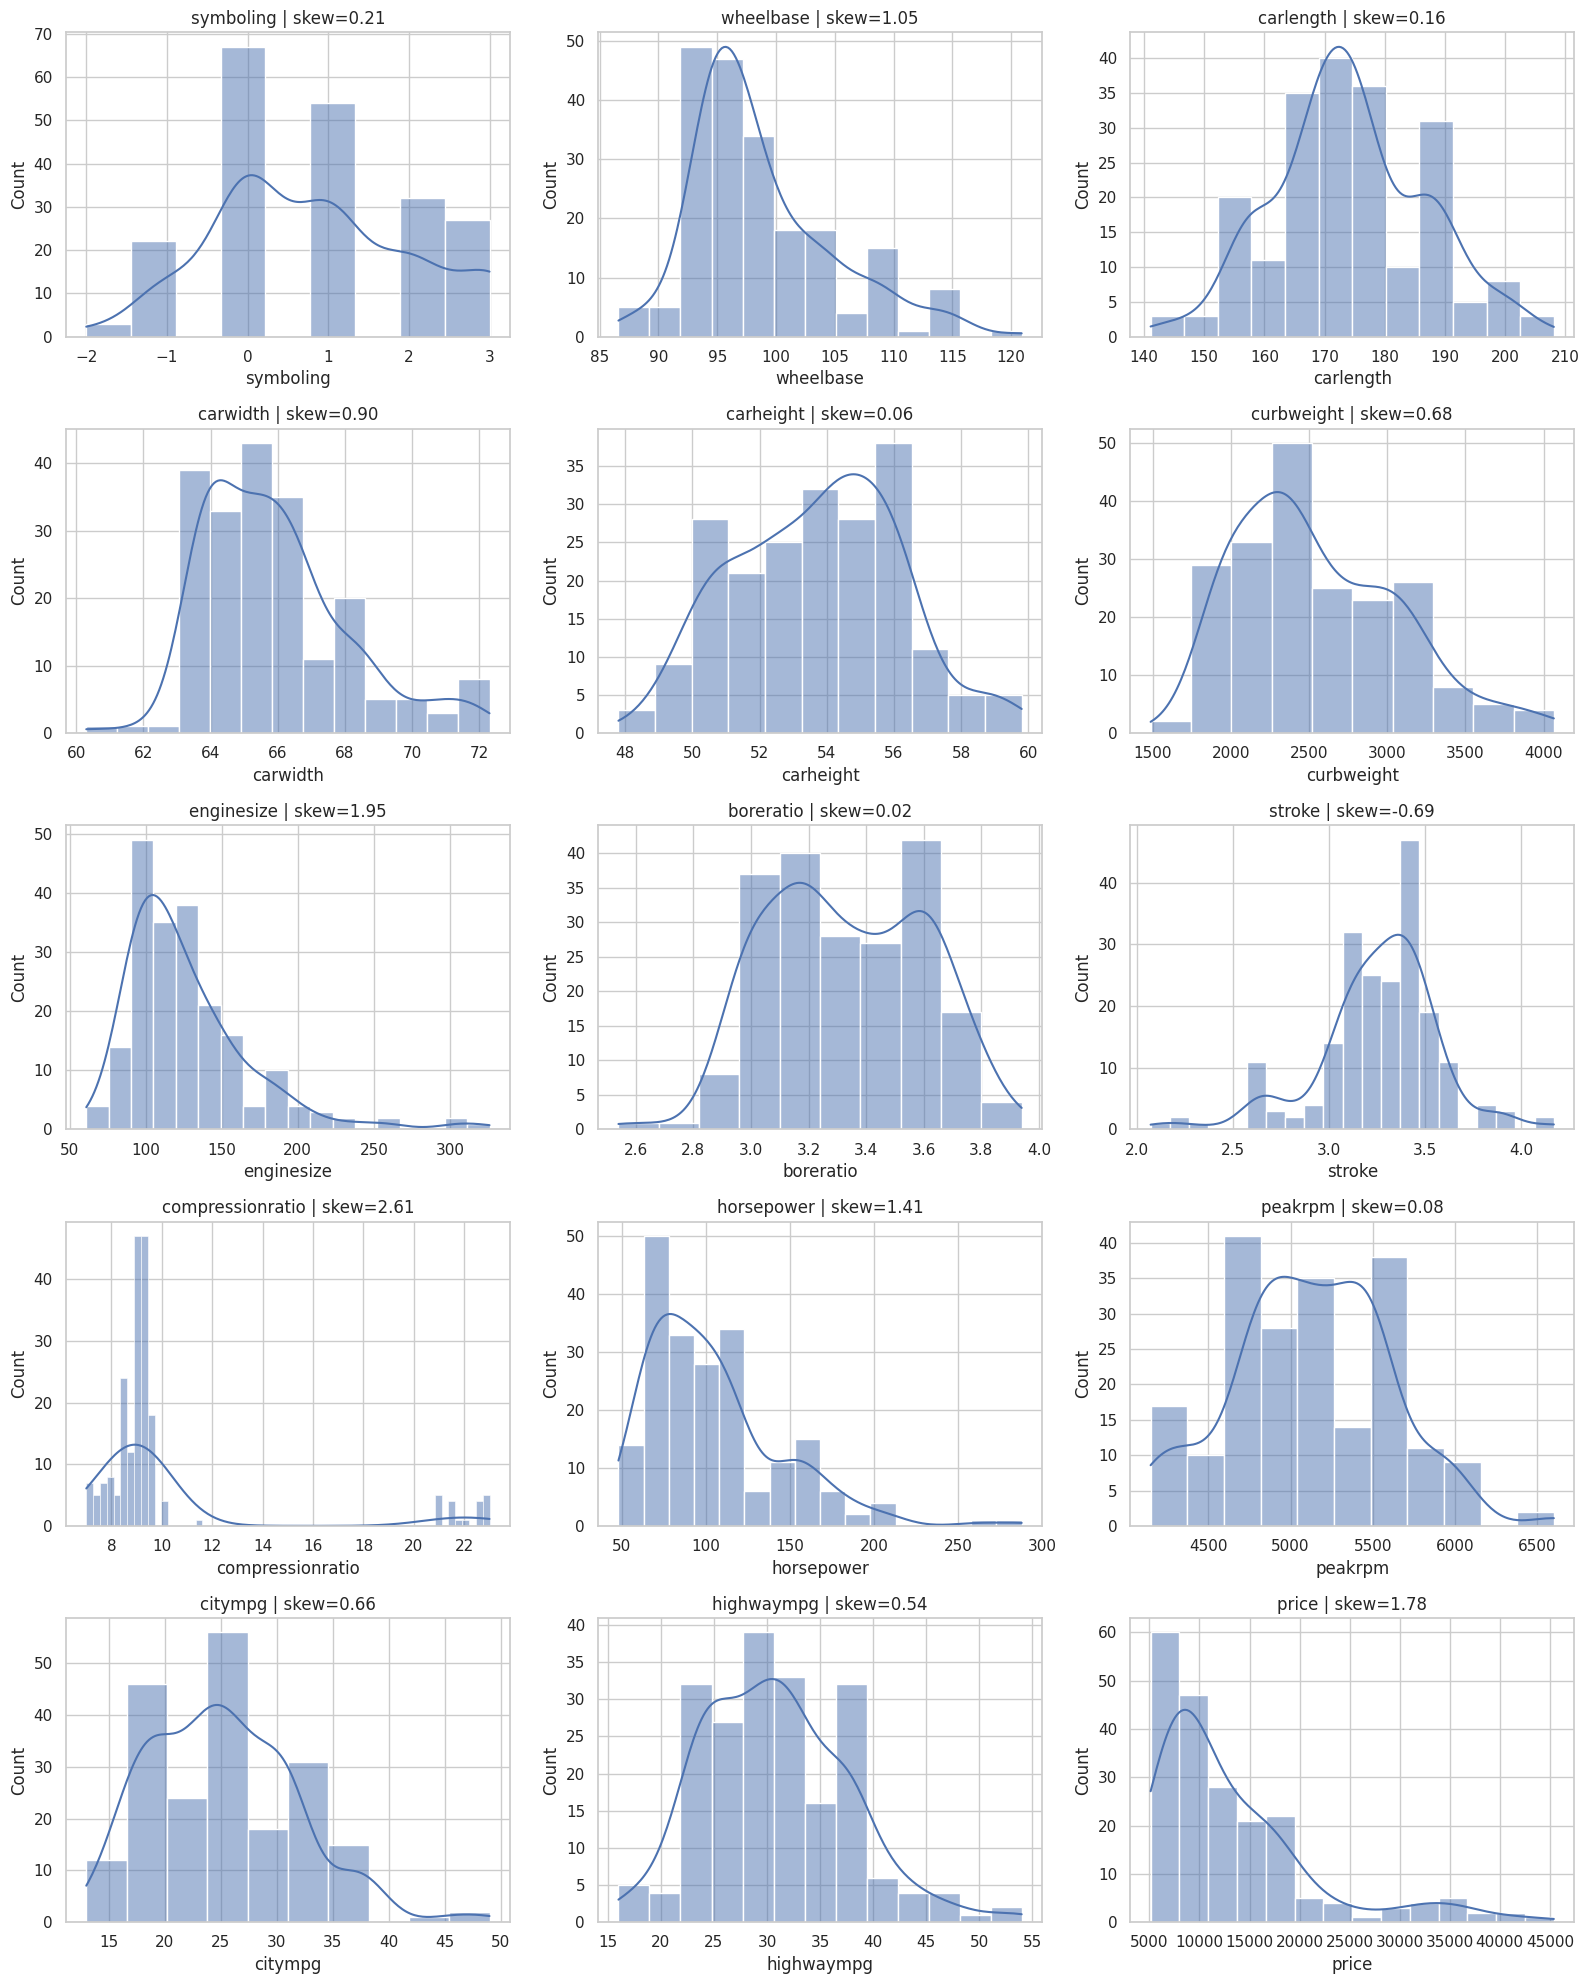

Коефіцієнти асиметрії:


,skewness
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,-0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997


Ознаки з вираженою асиметрією |skew| > 1:


,skewness
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214


Висновок: найбільшу увагу під час трансформації слід приділити ознакам із найбільшим абсолютним значенням асиметрії.


In [24]:
numeric_cols_all = data.select_dtypes(include=np.number).columns.tolist()
skew_before_all = data[numeric_cols_all].skew().sort_values(key=np.abs, ascending=False)

n = len(numeric_cols_all)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols_all):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'{col} | skew={data[col].skew():.2f}')
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

print('Коефіцієнти асиметрії:')
display(skew_before_all.to_frame('skewness'))

strong_skew = skew_before_all[skew_before_all.abs() > 1]
print('Ознаки з вираженою асиметрією |skew| > 1:')
display(strong_skew.to_frame('skewness'))

print('Висновок: найбільшу увагу під час трансформації слід приділити ознакам '
      'із найбільшим абсолютним значенням асиметрії.')


## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [25]:
X = data.drop(columns=['price'])
y = data['price']

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, car_ids, test_size=0.20, random_state=RANDOM_STATE
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)
print('ID train/test:', id_train.shape, id_test.shape)


X_train: (164, 24) | X_test: (41, 24)
y_train: (164,) | y_test: (41,)
ID train/test: (164,) (41,)


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [28]:
continuous_cols_initial = [
    c for c in X_train.select_dtypes(include=np.number).columns if c != 'symboling'
]

iqr_bounds = {}
outlier_counts = {}

for col in continuous_cols_initial:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_bounds[col] = (lower, upper)
    outlier_counts[col] = ((X_train[col] < lower) | (X_train[col] > upper)).sum()

outlier_table = pd.DataFrame.from_dict(
    outlier_counts, orient='index', columns=['Кількість потенційних викидів']
).sort_values('Кількість потенційних викидів', ascending=False)
display(outlier_table)

X_train_clip = X_train.copy()
X_test_clip = X_test.copy()

for col, (lower, upper) in iqr_bounds.items():
    X_train_clip[col] = X_train_clip[col].clip(lower, upper)
    X_test_clip[col] = X_test_clip[col].clip(lower, upper)


,Кількість потенційних викидів
compressionratio,20
stroke,16
carwidth,10
horsepower,7
enginesize,7
wheelbase,6
peakrpm,2
highwaympg,1
boreratio,1
curbweight,0


## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


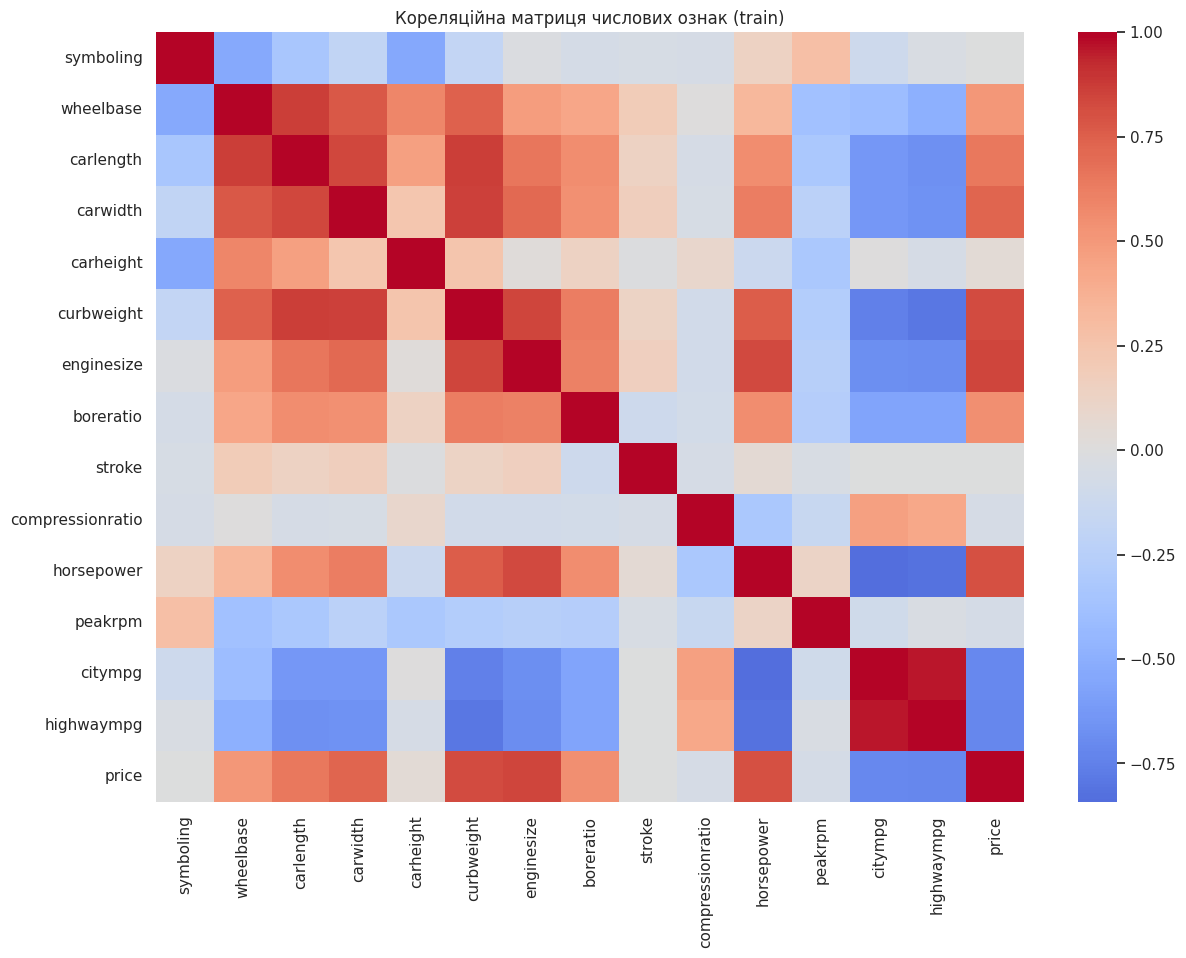

Сильно корельовані пари |r| > 0.85:


,Ознака 1,Ознака 2,r між ознаками,|r| ознаки 1 з price,|r| ознаки 2 з price
0,wheelbase,carlength,0.867043,0.504036,0.652071
1,carlength,curbweight,0.865988,0.652071,0.824212
2,carwidth,curbweight,0.858047,0.731623,0.824212
3,citympg,highwaympg,0.963620,0.711245,0.716460


Ознаки, які видаляються: ['carlength', 'carwidth', 'citympg', 'wheelbase']
Після відбору: (164, 20) (41, 20)


In [32]:
train_num_for_corr = X_train_clip.select_dtypes(include=np.number).copy()
train_num_for_corr['price'] = y_train

plt.figure(figsize=(14, 10))
sns.heatmap(train_num_for_corr.corr(), cmap='coolwarm', center=0)
plt.title('Кореляційна матриця числових ознак (train)')
plt.show()

feature_corr = train_num_for_corr.drop(columns='price').corr()
target_corr = train_num_for_corr.corr()['price'].drop('price').abs()

strong_pairs = []
num_features = feature_corr.columns.tolist()
for i in range(len(num_features)):
    for j in range(i + 1, len(num_features)):
        r = feature_corr.iloc[i, j]
        if abs(r) > 0.85:
            a, b = num_features[i], num_features[j]
            strong_pairs.append((a, b, r, target_corr[a], target_corr[b]))

pairs_df = pd.DataFrame(
    strong_pairs,
    columns=['Ознака 1', 'Ознака 2', 'r між ознаками',
             '|r| ознаки 1 з price', '|r| ознаки 2 з price']
)
print('Сильно корельовані пари |r| > 0.85:')
display(pairs_df)

to_drop = set()
for a, b, r, ca, cb in strong_pairs:
    if a in to_drop or b in to_drop:
        continue
    if ca < cb:
        to_drop.add(a)
    else:
        to_drop.add(b)

to_drop = sorted(to_drop)
print('Ознаки, які видаляються:', to_drop)

X_train_sel = X_train_clip.drop(columns=to_drop)
X_test_sel = X_test_clip.drop(columns=to_drop)

print('Після відбору:', X_train_sel.shape, X_test_sel.shape)


## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [34]:
continuous_cols = [
    c for c in X_train_sel.select_dtypes(include=np.number).columns if c != 'symboling'
]
discrete_cols = ['symboling'] if 'symboling' in X_train_sel.columns else []
categorical_cols = X_train_sel.select_dtypes(exclude=np.number).columns.tolist()

continuous_pipe = Pipeline([
    ('yeo_johnson', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scaler', StandardScaler())
])

symboling_pipe = Pipeline([
    ('scaler', StandardScaler())
])

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer([
    ('continuous', continuous_pipe, continuous_cols),
    ('symboling', symboling_pipe, discrete_cols),
    ('categorical', ohe, categorical_cols)
], remainder='drop')

print('Неперервні числові:', continuous_cols)
print('Дискретна числова:', discrete_cols)
print('Категоріальні:', categorical_cols)
print('\nПередобробка сформована в єдиний ColumnTransformer.')


Неперервні числові: ['carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']
Дискретна числова: ['symboling']
Категоріальні: ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

Передобробка сформована в єдиний ColumnTransformer.


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [35]:
numeric_check_pipe = Pipeline([
    ('yeo_johnson', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scaler', StandardScaler())
])

before_skew = X_train_sel[continuous_cols].skew()
transformed_num = numeric_check_pipe.fit_transform(X_train_sel[continuous_cols])
transformed_num_df = pd.DataFrame(
    transformed_num, columns=continuous_cols, index=X_train_sel.index
)
after_skew = transformed_num_df.skew()

skew_compare = pd.DataFrame({
    'До трансформації': before_skew,
    'Після Yeo-Johnson + StandardScaler': after_skew,
    '|skew| до': before_skew.abs(),
    '|skew| після': after_skew.abs()
}).sort_values('|skew| до', ascending=False)

display(skew_compare)
print('Середнє |skew| до:', round(before_skew.abs().mean(), 3))
print('Середнє |skew| після:', round(after_skew.abs().mean(), 3))
print('Висновок: Yeo–Johnson у більшості випадків зменшує асиметрію, '
      'а StandardScaler приводить числові ознаки до спільного масштабу.')


,До трансформації,Після Yeo-Johnson + StandardScaler,|skew| до,|skew| після
enginesize,0.962394,0.044834,0.962394,0.044834
horsepower,0.850735,0.066280,0.850735,0.066280
curbweight,0.712433,0.049894,0.712433,0.049894
stroke,-0.397600,0.015846,0.397600,0.015846
highwaympg,0.243761,-0.012188,0.243761,0.012188
boreratio,0.062963,-0.005941,0.062963,0.005941
compressionratio,0.055710,0.004872,0.055710,0.004872
peakrpm,0.039773,-0.003589,0.039773,0.003589
carheight,0.028154,-0.005170,0.028154,0.005170


Середнє |skew| до: 0.373
Середнє |skew| після: 0.023
Висновок: Yeo–Johnson у більшості випадків зменшує асиметрію, а StandardScaler приводить числові ознаки до спільного масштабу.


## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [36]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=100.0, max_iter=20000),
    'Random Forest': RandomForestRegressor(
        n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'SVR': SVR(kernel='rbf', C=1000, epsilon=0.1)
}

pipelines = {
    name: Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    for name, model in models.items()
}

print('Створено моделей:', len(pipelines))
print(list(pipelines.keys()))


Створено моделей: 6
['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest', 'Gradient Boosting', 'SVR']


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


In [37]:
results = []
predictions = {}
train_scores = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train_sel, y_train)
    pred = pipe.predict(X_test_sel)
    train_pred = pipe.predict(X_train_sel)

    predictions[name] = pred
    train_scores[name] = r2_score(y_train, train_pred)

    results.append({
        'Модель': name,
        'R² test': r2_score(y_test, pred),
        'R² train': train_scores[name],
        'MAE': mean_absolute_error(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'MAPE, %': mean_absolute_percentage_error(y_test, pred) * 100
    })

results_df = pd.DataFrame(results).sort_values('R² test', ascending=False).reset_index(drop=True)
display(results_df.style.format({
    'R² test': '{:.4f}', 'R² train': '{:.4f}',
    'MAE': '{:.2f}', 'MSE': '{:.2f}', 'MAPE, %': '{:.2f}'
}))

best_name = results_df.loc[0, 'Модель']
print(f'Найвище R² на test у поточному запуску має: {best_name}')
print('Різниця між train і test R² допомагає помітити можливе перенавчання.')


,Модель,R² test,R² train,MAE,MSE,"MAPE, %"
0,Random Forest,0.9509,0.9856,1432.82,3873574.99,10.41
1,Gradient Boosting,0.9291,0.9921,1703.69,5596688.22,12.64
2,Ridge Regression,0.7957,0.9619,2712.77,16129423.33,23.07
3,Lasso Regression,0.7751,0.8528,2894.50,17752244.41,23.48
4,Linear Regression,0.5481,0.9928,4078.23,35676914.46,29.97
5,SVR,0.5080,0.5636,3568.60,38844388.08,21.12


Найвище R² на test у поточному запуску має: Random Forest
Різниця між train і test R² допомагає помітити можливе перенавчання.


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


**Пояснення:** `price` - це неперервна числова величина, тому її прогнозування є
задачею регресії. Logistic Regression, незважаючи на назву, є класифікаційним
алгоритмом: вона оцінює ймовірність належності об'єкта до певного класу і не
призначена для безпосереднього прогнозування довільної неперервної ціни.

У цій роботі використані Linear Regression, Ridge, Lasso, Random Forest Regressor,
Gradient Boosting Regressor та SVR - усі вони можуть розв'язувати задачу регресії
та повертати числовий прогноз ціни автомобіля.


## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


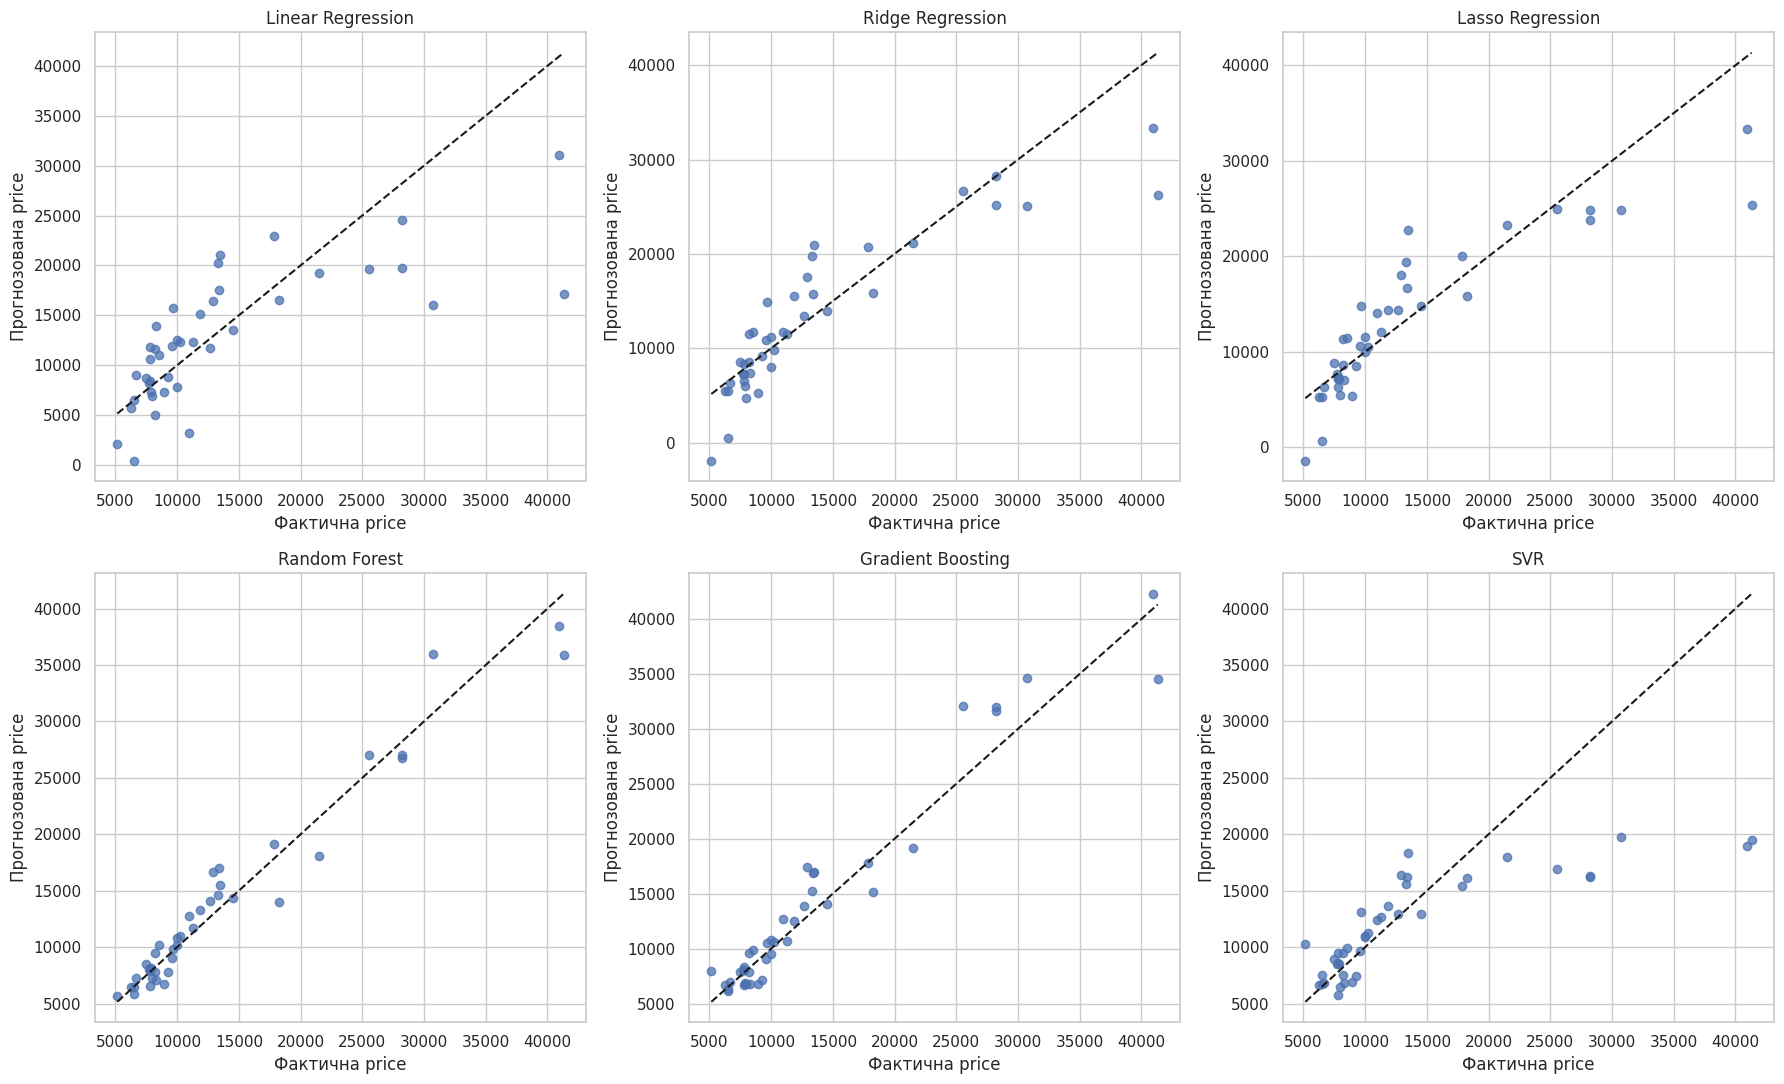

Інтерпретація: чим ближче точки до пунктирної діагоналі, тим точніший прогноз. Точки далеко від лінії відповідають автомобілям із більшими помилками прогнозу.


In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

y_min, y_max = y_test.min(), y_test.max()

for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, pred, alpha=0.75)
    ax.plot([y_min, y_max], [y_min, y_max], 'k--', linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel('Фактична price')
    ax.set_ylabel('Прогнозована price')

plt.tight_layout()
plt.show()

print('Інтерпретація: чим ближче точки до пунктирної діагоналі, тим точніший прогноз. '
      'Точки далеко від лінії відповідають автомобілям із більшими помилками прогнозу.')


## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [39]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_test_sel.index, size=min(10, len(X_test_sel)), replace=False)

rf_pipe = pipelines['Random Forest']
X_sample = X_test_sel.loc[sample_idx]
actual = y_test.loc[sample_idx]
ids_sample = id_test.loc[sample_idx]
rf_pred = rf_pipe.predict(X_sample)

forecast_10 = pd.DataFrame({
    'car_ID': ids_sample.values,
    'Фактична ціна': actual.values,
    'Прогнозована ціна': rf_pred
})
forecast_10['Абсолютна помилка'] = (
    forecast_10['Фактична ціна'] - forecast_10['Прогнозована ціна']
).abs()
forecast_10['Абсолютна відсоткова помилка, %'] = (
    forecast_10['Абсолютна помилка'] / forecast_10['Фактична ціна'] * 100
)

display(forecast_10.round(2))
print('Середня абсолютна помилка для цих 10 авто:',
      round(forecast_10['Абсолютна помилка'].mean(), 2))
print('Середня абсолютна відсоткова помилка:',
      round(forecast_10['Абсолютна відсоткова помилка, %'].mean(), 2), '%')


,car_ID,Фактична ціна,Прогнозована ціна,Абсолютна помилка,"Абсолютна відсоткова помилка, %"
0,26,6692.0,7238.09,546.09,8.16
1,176,9988.0,10806.63,818.63,8.20
2,148,10198.0,10985.99,787.99,7.73
3,17,41315.0,35895.79,5419.21,13.12
4,69,28248.0,26734.33,1513.67,5.36
5,147,7463.0,8493.54,1030.54,13.81
6,144,9960.0,10176.61,216.61,2.17
7,85,14489.0,14322.59,166.41,1.15
8,195,12940.0,16665.96,3725.96,28.79
9,160,7788.0,7915.11,127.11,1.63


Середня абсолютна помилка для цих 10 авто: 1435.22
Середня абсолютна відсоткова помилка: 9.01 %


## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.


### Висновки

У лабораторній роботі було виконано повний цикл побудови моделей машинного навчання
для прогнозування ціни автомобіля. Дані перевірено на пропуски та дублікати,
`car_ID` збережено лише як ідентифікатор і виключено з набору предикторів.

Потенційні викиди в неперервних числових ознаках були визначені методом IQR.
Замість видалення спостережень крайні значення обмежено межами, розрахованими
тільки за навчальною вибіркою. Кореляційний аналіз і відбір сильно
корельованих ознак також виконувалися лише на train. Для числових ознак
застосовано Yeo-Johnson та StandardScaler, для `symboling` - StandardScaler,
а категоріальні змінні закодовано One-Hot Encoding з обробкою невідомих категорій.

Було побудовано шість регресійних моделей: Linear Regression, Ridge, Lasso,
Random Forest, Gradient Boosting та SVR. Їх необхідно порівнювати за таблицею,
отриманою в пункті 11: краще значення характеризується більшим R² та меншими
MAE, MSE і MAPE. Модель з першим рядком таблиці має найбільше тестове R² у
конкретному запуску. Порівняння `R² train` і `R² test` дає змогу оцінити можливі
ознаки перенавчання: велика перевага train над test може свідчити про нього.

Графіки фактичних і прогнозованих значень показують якість наближення:
чим ближче точки до лінії ідеального прогнозу, тим точніша модель.
Попередня обробка робить числові розподіли менш асиметричними, приводить ознаки
до порівнюваного масштабу та дозволяє коректно використовувати категоріальні
дані в усіх побудованих моделях.


## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.
